Na primeira parte, iremos importar o arquivo em csv e fazer uma análise da base de dados, para saber o tamanho, tipo das variáveis e se há valores nulls ou vazios

In [ ]:
#Libs
import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#importando o arquivo
df_nps = idhm = pd.read_csv('desafio_nps_fase_1.csv')
df_nps.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


In [ ]:
#Tamanho da Base de Dados
df_nps.shape

(2500, 19)

In [ ]:
#tipos das colunas
df_nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


In [ ]:
#Valores Nulos?
df_nps.isnull().sum().sum()

#Soma da Soma para verificar quantidade de dados nulos no df

np.int64(0)

In [ ]:
#dados estatísticos sobre NPS
df_nps['nps_score'].describe()

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


In [ ]:
#verificação se tem id de cliente repetido na base
print("COUNT:", df_nps['customer_id'].count())
print("COUNT DISTINCT:", df_nps['customer_id'].nunique())

COUNT: 2500
COUNT DISTINCT: 2500


Vamos adicionar algumas colunas:

*   classificação do cliente em promotor, neutro ou detrator
*   Score por faixas decimais (para facilitar a visualização nos gráficos e nas análises)
*   Tratar alguns valores relativos para verificação posterior de correlação (por exemplo: "quanto o frete representa do valor total" e "qual o % do valor de desconto sobre o total"). Essas colunas ajudarão a responder algumas hipóteses como "será que quem tem mais desconto no valor do produto, tem um nps maior?"


In [ ]:
#Criando a classificação de promotor/neutro/detrator. O nome da coluna e das variáveis estão em inglês para manter o padrão da base
def classify(n):
    if n >= 9:
        return 'promoter'
    elif n >= 7:
        return 'neutral'
    else:
        return 'detractor'

df_nps['nps_type'] = df_nps['nps_score'].apply(classify)

#conferindo se deu certo
#df_nps.head(20)

verificacao = df_nps[['nps_score'	, 'nps_type']].drop_duplicates()

print(verificacao)

      nps_score   nps_type
0           6.9  detractor
1           2.4  detractor
2           4.8  detractor
3           5.9  detractor
4           6.1  detractor
...         ...        ...
554         8.9    neutral
941         9.9   promoter
979         9.3   promoter
982         8.7    neutral
1620        9.7   promoter

[101 rows x 2 columns]


In [ ]:
#Aqui será agrupado também as faixas de score pelo valor decimal, apenas para realizar algumas visualizações.
#Mais adiante fiz um gráfico de barras com todos os valores decimais e a visualização ficou horrível, por isso agrupei o nps pelo valor inteiro aqui
df_nps['nps_score_int'] = df_nps['nps_score'].astype(int)


In [ ]:
#Aqui vamos adicionar as colunas de % de desconto e do valor do frete
df_nps['perc_discount'] = df_nps['discount_value']/df_nps['order_value']

df_nps['perc_freight'] = df_nps['freight_value'] /df_nps['order_value']

Agora vamos plotar distribuição do nps num gráfico de barra, para verificar visualmente como estão distribuídos os scores de NPS

In [ ]:
#preparacao da base para o gráfico
df_nps_grafico = (df_nps.groupby(['nps_score_int', 'nps_type'])['customer_id'].count().reset_index(name='number_of_clients'))
df_nps_grafico.head(10)

,nps_score_int,nps_type,number_of_clients
0,0,detractor,272
1,1,detractor,191
2,2,detractor,286
3,3,detractor,339
4,4,detractor,378
5,5,detractor,351
6,6,detractor,292
7,7,neutral,173
8,8,neutral,108
9,9,promoter,68


(array([  0.,  50., 100., 150., 200., 250., 300., 350., 400.]),
 [Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250'),
  Text(0, 300.0, '300'),
  Text(0, 350.0, '350'),
  Text(0, 400.0, '400')])

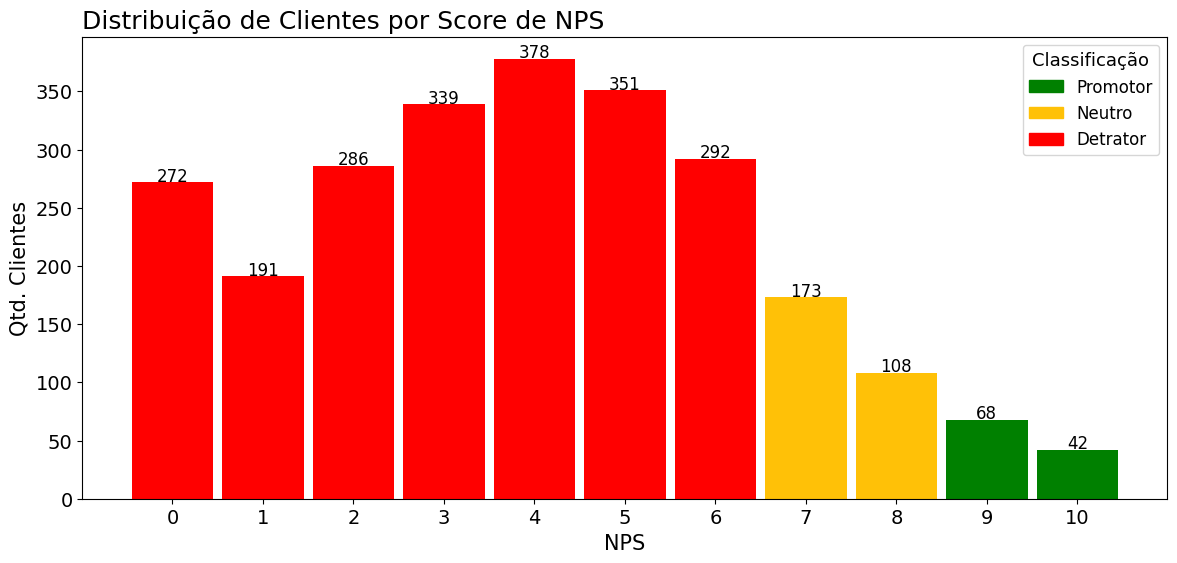

In [ ]:
#Tamanho da Figura
plt.figure(figsize=(14,6))

# Mapa de cores
cores = {
    'promoter': 'green',
    'neutral': '#FFC107',  # amarelo mais visível
    'detractor': 'red'
}

# Aplicar cores
cores_barras = df_nps_grafico['nps_type'].map(cores)

#Plotagem
plt.bar(df_nps_grafico['nps_score_int'],
        df_nps_grafico['number_of_clients'],
        width=0.9,
        color = cores_barras

        )

#Rótulo de dados para as barras
for i in range(len(df_nps_grafico)):
    plt.text(
        x=df_nps_grafico['nps_score_int'].iloc[i],
        y=df_nps_grafico['number_of_clients'].iloc[i] + 1,
        s=str(df_nps_grafico['number_of_clients'].iloc[i]),
        ha='center',
        fontsize=12
    )

#Titulo
plt.title('Distribuição de Clientes por Score de NPS', loc = 'left', fontsize = 18)

# Criar legenda
legendas = [
    mpatches.Patch(color='green', label='Promotor'),
    mpatches.Patch(color='#FFC107', label='Neutro'),
    mpatches.Patch(color='red', label='Detrator')
]

plt.legend(handles=legendas, fontsize=12, title='Classificação', title_fontsize=13)

#Labels
plt.xlabel('NPS', fontsize = 15)
plt.ylabel('Qtd. Clientes', fontsize = 15)

# Aumentar fonte dos ticks
#plt.xticks(rotation=90, fontsize=14)
plt.xticks(range(0, 11), fontsize=14)
plt.yticks(fontsize=14)

A distribuição está muito concentrada nos detratores, com valores concentrados no 0 e

Vamos agora verificar quais as variáveis que possuem maior correlação com o NPS

In [ ]:
# Correlação com NPS
correlacao = df_nps.corr(numeric_only=True)['nps_score'].sort_values()
correlacao

,nps_score
delivery_delay_days,-0.597260
complaints_count,-0.496800
customer_service_contacts,-0.350845
resolution_time_days,-0.191392
perc_freight,-0.066850
freight_value,-0.041087
customer_age,-0.009936
customer_tenure_months,-0.009711
perc_discount,-0.009399
delivery_time_days,0.000925


Aqui já podemos concluir algumas coisas:


*   Pela correlação negativa na variável 'delivery_delay_days', pode-se concluir que quanto maior atraso na entrega, maior as chances do nps ser baixo.

*   Quanto maior a quantidade de reclamações ('complaints_count') e a quantidade de contatos dos clientes ('customer_service_contacts') durante a compra, maior é o impacto negativo no nps.


*  Embora a variável 'resolution_time_days' não tenha uma correlação tão alta quanto as outras, há um leve sinal de que quanto maior o tempo de resolução do problema, menor é o NPS.



*   A correlação positiva na variável 'repeat_purchase_30d', indica que quanto maior o nps, maiores são as chances do cliente realizar uma nova compra em 30 dias.



*   O percentual de desconto ou de frete não impactam no NPS










Vamos verificare agora as correlações entre os fatores negativos:

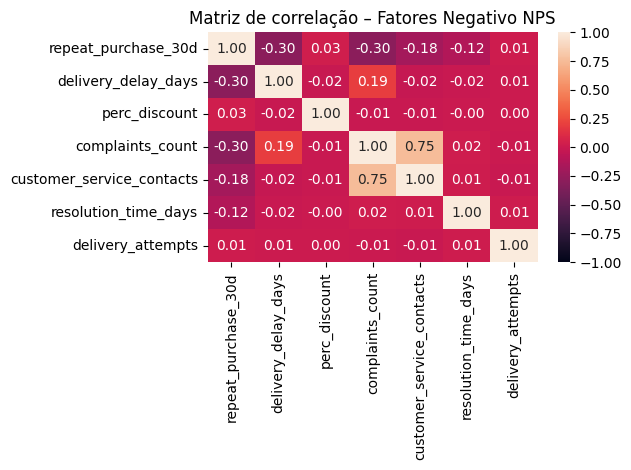

In [ ]:
cols_corr = [c for c in ['repeat_purchase_30d', 'delivery_delay_days','perc_discount',  'complaints_count', 'customer_service_contacts', 'resolution_time_days', 'delivery_attempts'] if c in df_nps.columns]
corr = df_nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – Fatores Negativo NPS")
plt.tight_layout()
plt.show()

Notamos acima que há uma correlação alta entre quantidade de contatos e reclamações, o que leva a concluir que quanto mais os clientes que mais entram em contato com o customer service são os que mais estão reclamando. O que serve como indicador de que a área de atendimento ao consumidor não está dando conta dos problemas.

Embora seja um coeficiente menor de 0.19, há correlação pequena entre a quantidade de dias de atraso e a quantidade de reclamações.

O percentual de desconto não impacta no indicador de novas compras após 30 dias

Abaixo vamos ver como a média desses indicadores negativos se distribuem por cluster e por faixa de nps

In [ ]:
# Médias por tipo de cliente
group_analysis = df_nps.groupby('nps_type')[[
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]].mean()
group_analysis

,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days
nps_type,,,,
detractor,2.414889,4.442390,1.632053,5.694642
neutral,1.053381,2.693950,1.007117,4.615658
promoter,0.718182,2.272727,0.672727,3.700000


In [ ]:
# Médias por Score Inteiro
group_analysis = df_nps.groupby('nps_score_int')[[
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]].mean()


group_analysis

,delivery_delay_days,complaints_count,customer_service_contacts,resolution_time_days
nps_score_int,,,,
0,3.944853,5.474265,2.397059,6.268382
1,3.141361,4.905759,1.853403,6.638743
2,2.769231,4.779720,1.800699,5.905594
3,2.389381,4.610619,1.672566,5.660767
4,1.989418,4.325397,1.460317,5.703704
5,1.740741,4.182336,1.287749,5.131054
6,1.558219,3.116438,1.198630,5.041096
7,1.213873,2.768786,1.057803,4.664740
8,0.796296,2.574074,0.925926,4.537037


Vamos verificar a partir de quantos dias de atraso em média, o nps começa a cair:

In [ ]:
# Médias NPS por Atraso
atraso_analysis = df_nps.groupby('delivery_delay_days')[[
    'nps_score'
]].describe()
atraso_analysis

nps_score                                               
                        count      mean       std  min  25%   50%  75%   max
delivery_delay_days                                                         
0                       277.0  6.856679  2.013667  1.1  5.5  6.80  8.5  10.0
1                       615.0  5.546179  2.184379  0.0  4.1  5.50  7.0  10.0
2                       646.0  4.580186  2.039770  0.0  3.1  4.60  6.0  10.0
3                       525.0  3.436762  1.998215  0.0  2.1  3.40  4.8   9.4
4                       270.0  2.444444  1.831272  0.0  0.9  2.30  3.6   8.3
5                       116.0  1.481034  1.598962  0.0  0.0  1.25  2.4   6.3
6                        34.0  1.097059  1.243281  0.0  0.0  0.70  1.9   4.6
7                        14.0  0.292857  0.415959  0.0  0.0  0.00  0.6   1.1
8                         3.0  0.000000  0.000000  0.0  0.0  0.00  0.0   0.0

O resultado acima já mostra que, até com a entrega no prazo, o NPS ainda é baixo. Vamos investigar o atendimento

In [ ]:
# Médias NPS por Quantidade de Contatos
atraso_analysis = df_nps.groupby('customer_service_contacts')[[
    'nps_score'
]].mean()
atraso_analysis

,nps_score
customer_service_contacts,
0,5.543502
1,4.657108
2,4.116406
3,3.201911
4,2.654545
5,2.238235
6,0.742857
7,1.200000


In [ ]:
# Médias NPS por Tempo de resolução
tempo_res_analysis = df_nps.groupby('complaints_count')[[
    'nps_score'
]].mean()
tempo_res_analysis

,nps_score
complaints_count,
0,8.517391
1,7.770492
2,6.052347
3,4.910059
4,4.219167
5,3.645270
6,3.062030
7,2.813609
8,2.065079


In [ ]:
# Médias NPS por Tempo de resolução
atraso_analysis = df_nps.groupby('resolution_time_days')[[
    'nps_score'
]].mean()
atraso_analysis

,nps_score
resolution_time_days,
0,5.320192
1,5.004167
2,4.817904
3,4.627848
4,4.442233
5,4.423295
6,4.324365
7,4.260563
8,3.965639


In [ ]:
df_sem_atraso = df_nps[df_nps['delivery_delay_days'] > 0]

df_sem_atraso.groupby('nps_score_int')[[
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]].mean()

,complaints_count,customer_service_contacts,resolution_time_days
nps_score_int,,,
0,5.474265,2.397059,6.268382
1,4.920213,1.845745,6.611702
2,4.758007,1.768683,5.882562
3,4.599388,1.642202,5.602446
4,4.303725,1.369628,5.616046
5,4.241830,1.228758,5.000000
6,3.205761,1.090535,4.765432
7,2.864662,0.917293,4.360902
8,2.875000,0.859375,4.140625


In [ ]:
df_com_atraso = df_nps[df_nps['delivery_delay_days'] > 0]

df_com_atraso.groupby('nps_score_int')[[
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days'
]].mean()

,complaints_count,customer_service_contacts,resolution_time_days
nps_score_int,,,
0,5.474265,2.397059,6.268382
1,4.920213,1.845745,6.611702
2,4.758007,1.768683,5.882562
3,4.599388,1.642202,5.602446
4,4.303725,1.369628,5.616046
5,4.241830,1.228758,5.000000
6,3.205761,1.090535,4.765432
7,2.864662,0.917293,4.360902
8,2.875000,0.859375,4.140625


In [ ]:
pivot = df_nps.pivot_table(
    values='nps_score',
    index='delivery_delay_days',
    columns='complaints_count',
    aggfunc='mean'
)
pivot

complaints_count,0,1,2,3,4,5,6,7,8,9,10,11
delivery_delay_days,,,,,,,,,,,,
0,8.517391,7.974074,7.302222,6.812500,6.064444,6.012500,4.543750,5.983333,3.825000,4.166667,9.100000,NaN
1,NaN,7.983871,6.914943,6.315267,5.473984,4.644444,4.248485,4.527907,3.694118,3.320000,1.566667,0.4
2,NaN,7.569565,6.094286,5.147863,4.603867,4.186290,3.366667,3.056522,1.654545,1.966667,3.200000,NaN
3,NaN,6.833333,5.147917,3.988496,3.635036,3.095146,2.438596,1.548649,1.350000,4.800000,1.400000,1.3
4,NaN,7.000000,3.707692,3.118182,2.704000,1.770588,1.717949,1.733333,1.325000,0.000000,NaN,NaN
5,NaN,6.300000,2.036364,1.796000,1.688462,1.365000,1.442857,0.450000,0.350000,0.000000,0.000000,NaN
6,NaN,NaN,0.000000,1.600000,1.000000,1.472727,0.733333,0.000000,0.000000,0.000000,0.700000,NaN
7,NaN,NaN,1.000000,0.000000,0.075000,0.450000,0.350000,NaN,0.200000,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


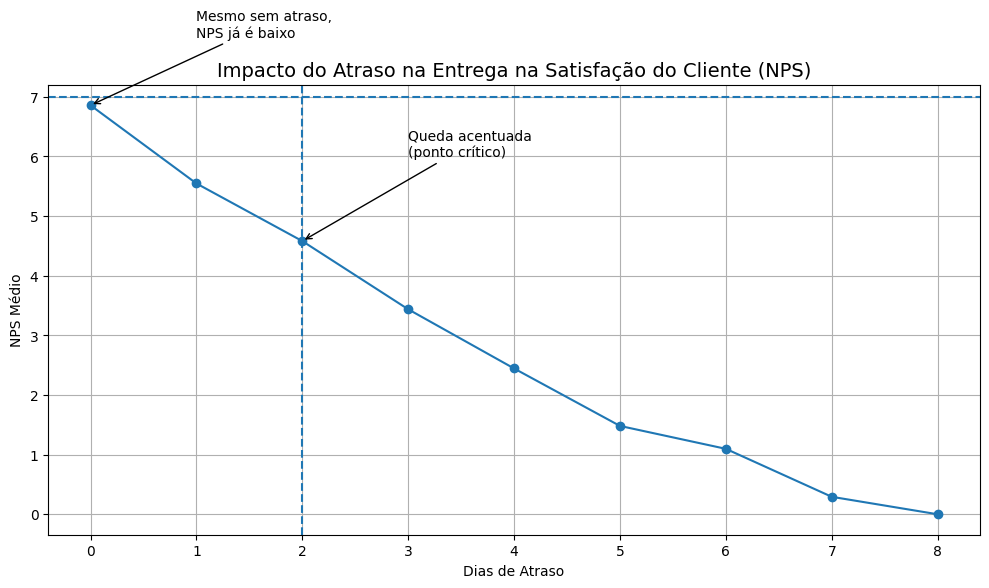

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar dados
nps_by_delay = df_nps.groupby('delivery_delay_days')['nps_score'].mean().reset_index()

# Criar figura
plt.figure(figsize=(10,6))

# Linha principal
plt.plot(
    nps_by_delay['delivery_delay_days'],
    nps_by_delay['nps_score'],
    marker='o'
)

# Linha de referência (zona neutra NPS = 7)
plt.axhline(y=7, linestyle='--')

# Destaque no ponto de ruptura (ex: 2 dias)
plt.axvline(x=2, linestyle='--')

# Títulos
plt.title('Impacto do Atraso na Entrega na Satisfação do Cliente (NPS)', fontsize=14)
plt.xlabel('Dias de Atraso')
plt.ylabel('NPS Médio')

# Anotação chave (baseline baixo)
plt.annotate(
    'Mesmo sem atraso,\nNPS já é baixo',
    xy=(0, nps_by_delay.loc[nps_by_delay['delivery_delay_days']==0, 'nps_score'].values[0]),
    xytext=(1, 8),
    arrowprops=dict(arrowstyle='->')
)

# Anotação ponto crítico
plt.annotate(
    'Queda acentuada\n(ponto crítico)',
    xy=(2, nps_by_delay.loc[nps_by_delay['delivery_delay_days']==2, 'nps_score'].values[0]),
    xytext=(3, 6),
    arrowprops=dict(arrowstyle='->')
)


plt.grid()
plt.tight_layout()
plt.show()

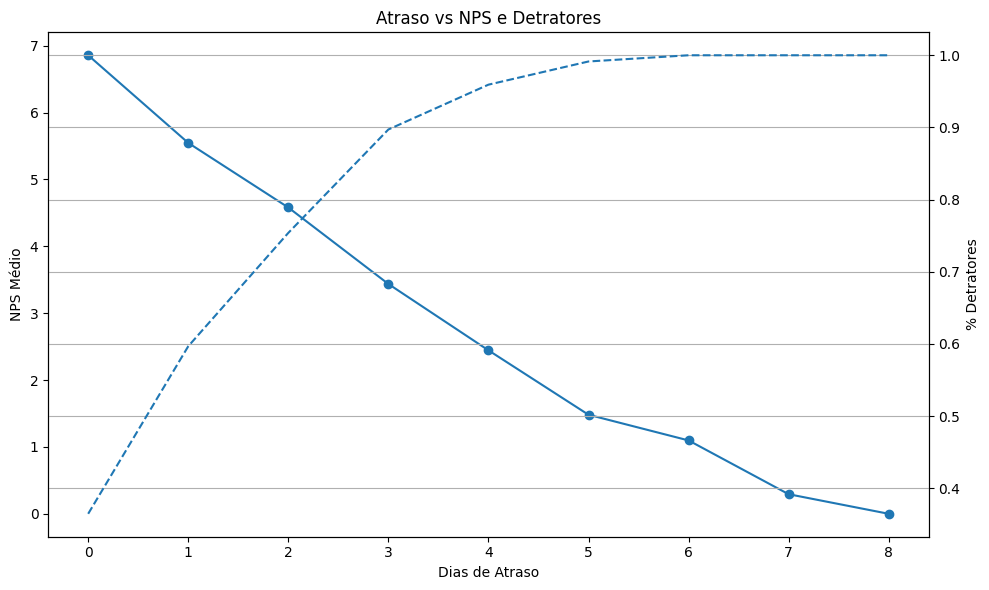

In [ ]:
df_nps['is_detractor'] = (df_nps['nps_score'] <= 6).astype(int)

detractor_rate = df_nps.groupby('delivery_delay_days')['is_detractor'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(10,6))

# NPS
ax1.plot(nps_by_delay['delivery_delay_days'], nps_by_delay['nps_score'], marker='o')
ax1.set_ylabel('NPS Médio')
ax1.set_xlabel('Dias de Atraso')

# Detratores
ax2 = ax1.twinx()
ax2.plot(detractor_rate['delivery_delay_days'], detractor_rate['is_detractor'], linestyle='--')
ax2.set_ylabel('% Detratores')

plt.title('Atraso vs NPS e Detratores')

plt.grid()
plt.tight_layout()
plt.show()

Vamos verificar se há problemas por região

In [ ]:
nps_region = df_nps.groupby('customer_region')['nps_score'].mean().sort_values()

print(nps_region)

customer_region
Centro-Oeste    4.209829
Sudeste         4.373846
Norte           4.382609
Nordeste        4.421649
Sul             4.490979
Name: nps_score, dtype: float64


Na média, o NPS é muito próximo entre as regiões

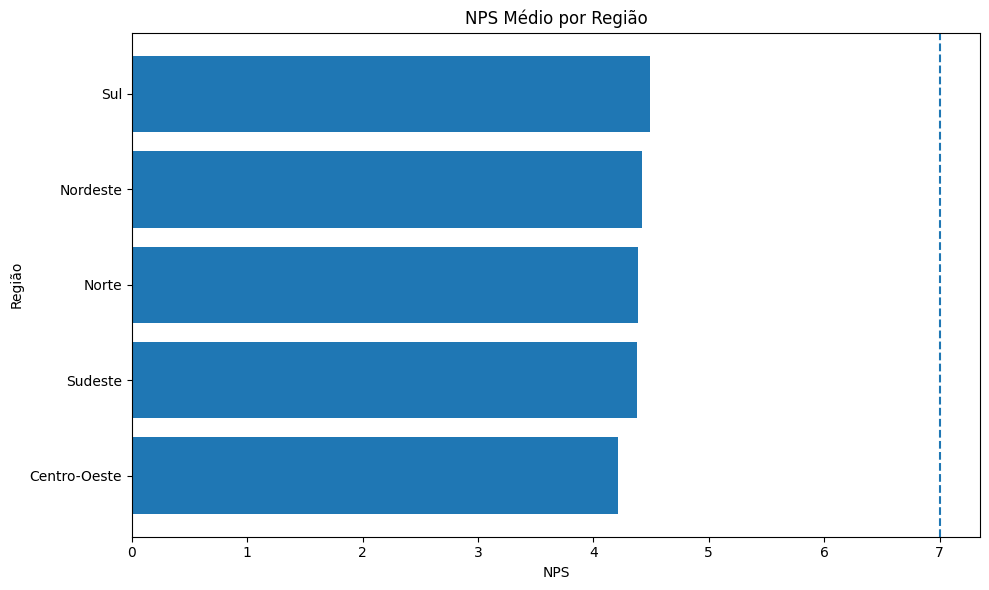

In [ ]:
import matplotlib.pyplot as plt

nps_region = df_nps.groupby('customer_region')['nps_score'].mean().sort_values()

plt.figure(figsize=(10,6))
plt.barh(nps_region.index, nps_region.values)

plt.axvline(x=7, linestyle='--')  # zona neutra

plt.title('NPS Médio por Região')
plt.xlabel('NPS')
plt.ylabel('Região')

plt.tight_layout()
plt.show()

Vamos verificar o atraso:

In [ ]:
delay_region = df_nps.groupby('customer_region')['delivery_delay_days'].mean().sort_values()

print(delay_region)

customer_region
Norte           2.144269
Sul             2.168906
Nordeste        2.185567
Sudeste         2.217308
Centro-Oeste    2.222222
Name: delivery_delay_days, dtype: float64


O atraso também é, na média, muito semelhante entre as regiões. Abaixo vamos ver como se comportam os nps com e sem atraso.

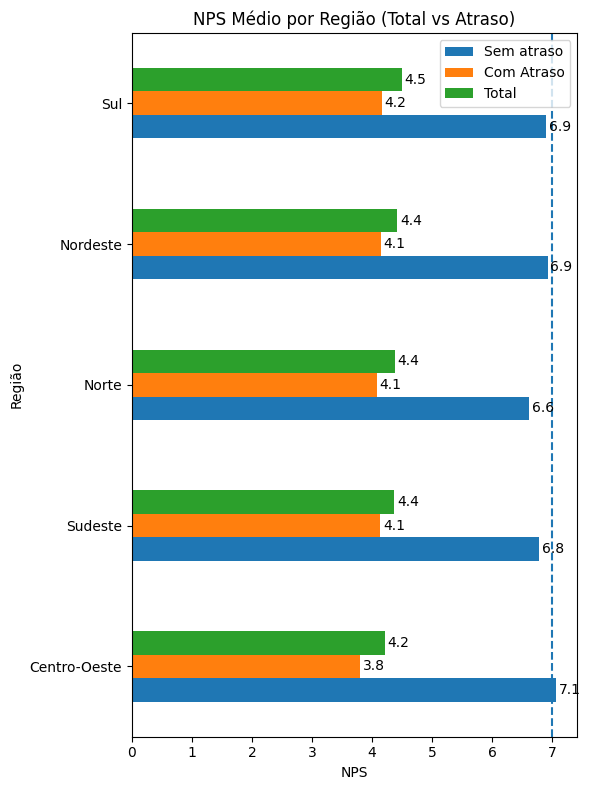

In [ ]:
df_no_delay = df_nps[df_nps['delivery_delay_days'] == 0]
df_com_delay = df_nps[df_nps['delivery_delay_days'] > 0]
nps_total = df_nps.groupby('customer_region')['nps_score'].mean()

nps_no_delay = df_no_delay.groupby('customer_region')['nps_score'].mean()
nps_com_delay = df_com_delay.groupby('customer_region')['nps_score'].mean()

comparison = pd.DataFrame({
    'Sem atraso': nps_no_delay,
    'Com Atraso': nps_com_delay,
    'Total': nps_total

}).sort_values('Total')

# Plot
ax = comparison.plot(kind='barh', figsize=(6,8))

# Adicionar rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)

# Linha de referência (zona neutra)
plt.axvline(x=7, linestyle='--')

#comparison.plot(kind='barh', figsize=(10,8))
plt.title('NPS Médio por Região (Total vs Atraso)')
plt.xlabel('NPS')
plt.ylabel('Região')
plt.tight_layout()
plt.show()

In [ ]:
df_nps.groupby('customer_region')[[
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts'
]].corrwith(df_nps['nps_score'])

,delivery_delay_days,complaints_count,customer_service_contacts
customer_region,,,
Centro-Oeste,-0.597246,-0.546885,-0.412278
Nordeste,-0.615112,-0.494398,-0.320535
Norte,-0.607666,-0.471568,-0.379703
Sudeste,-0.558015,-0.467420,-0.321078
Sul,-0.610252,-0.504476,-0.318766


In [ ]:
# Criar flag de atraso (1 = teve atraso, 0 = não teve)
df_nps['has_delay'] = (df_nps['delivery_delay_days'] > 0).astype(int)

# Agrupar por região e calcular percentual
delay_region = df_nps.groupby('customer_region')['has_delay'].mean().reset_index()

# Converter para %
delay_region['delay_pct'] = delay_region['has_delay'] * 100

# Ordenar do pior para o melhor
delay_region = delay_region.sort_values('delay_pct', ascending=False)

print(delay_region[['customer_region', 'delay_pct']])

  customer_region  delay_pct
3         Sudeste  90.961538
1        Nordeste  90.103093
2           Norte  87.944664
4             Sul  87.907869
0    Centro-Oeste  87.606838


A partir destes dados, já podemos organizar a apresentação gerencial